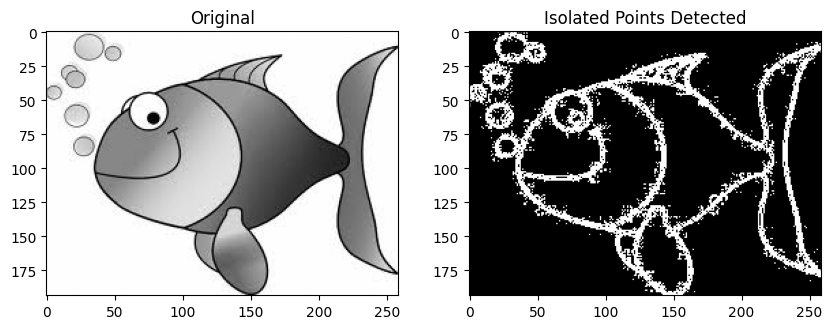

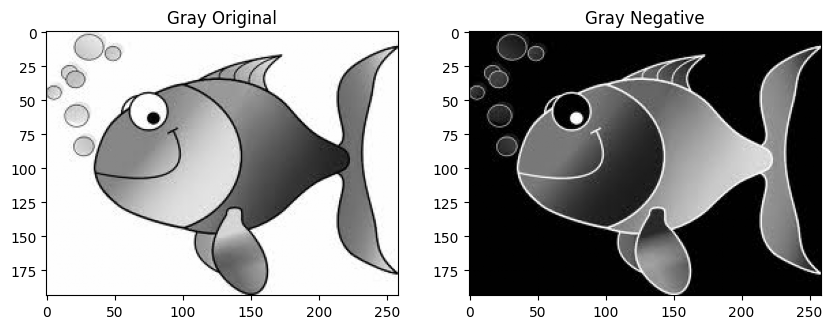

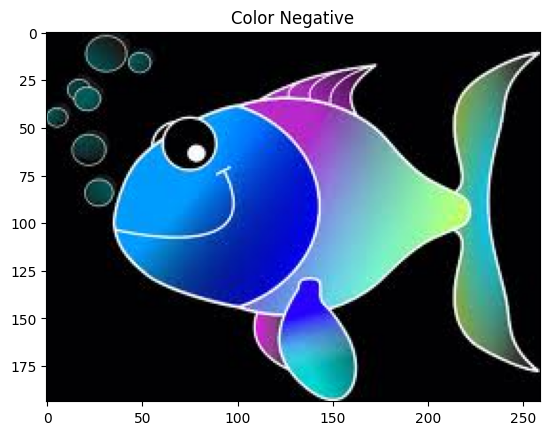

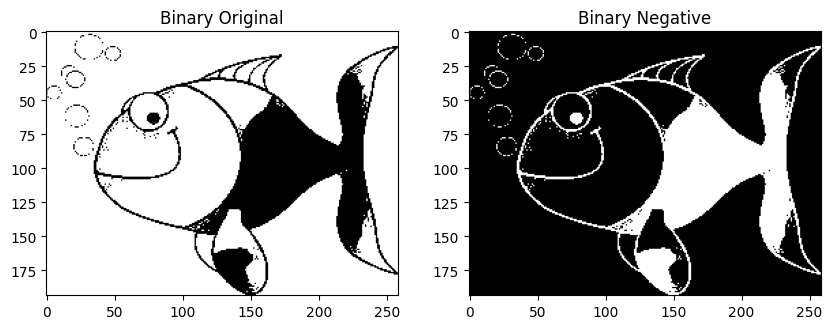

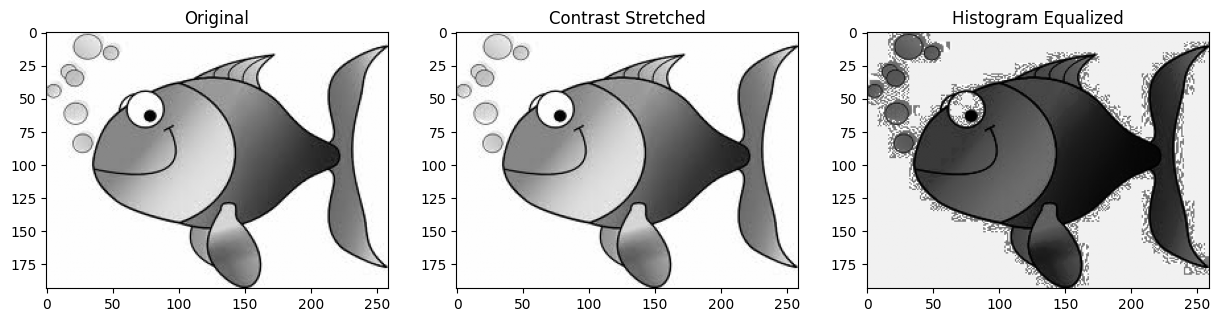

Contrast Stretching: Linear scaling of intensity values
Histogram Equalization: Non-linear redistribution of intensities


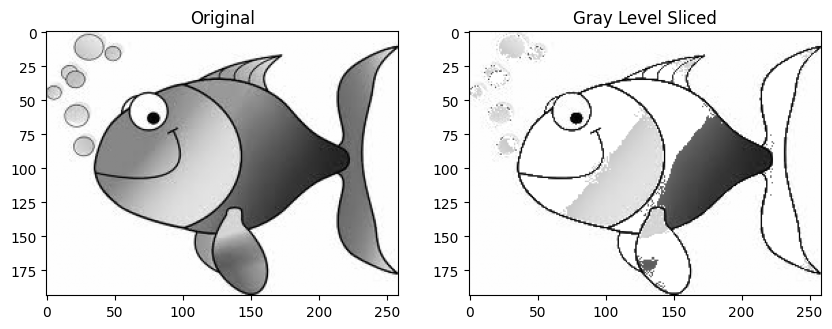

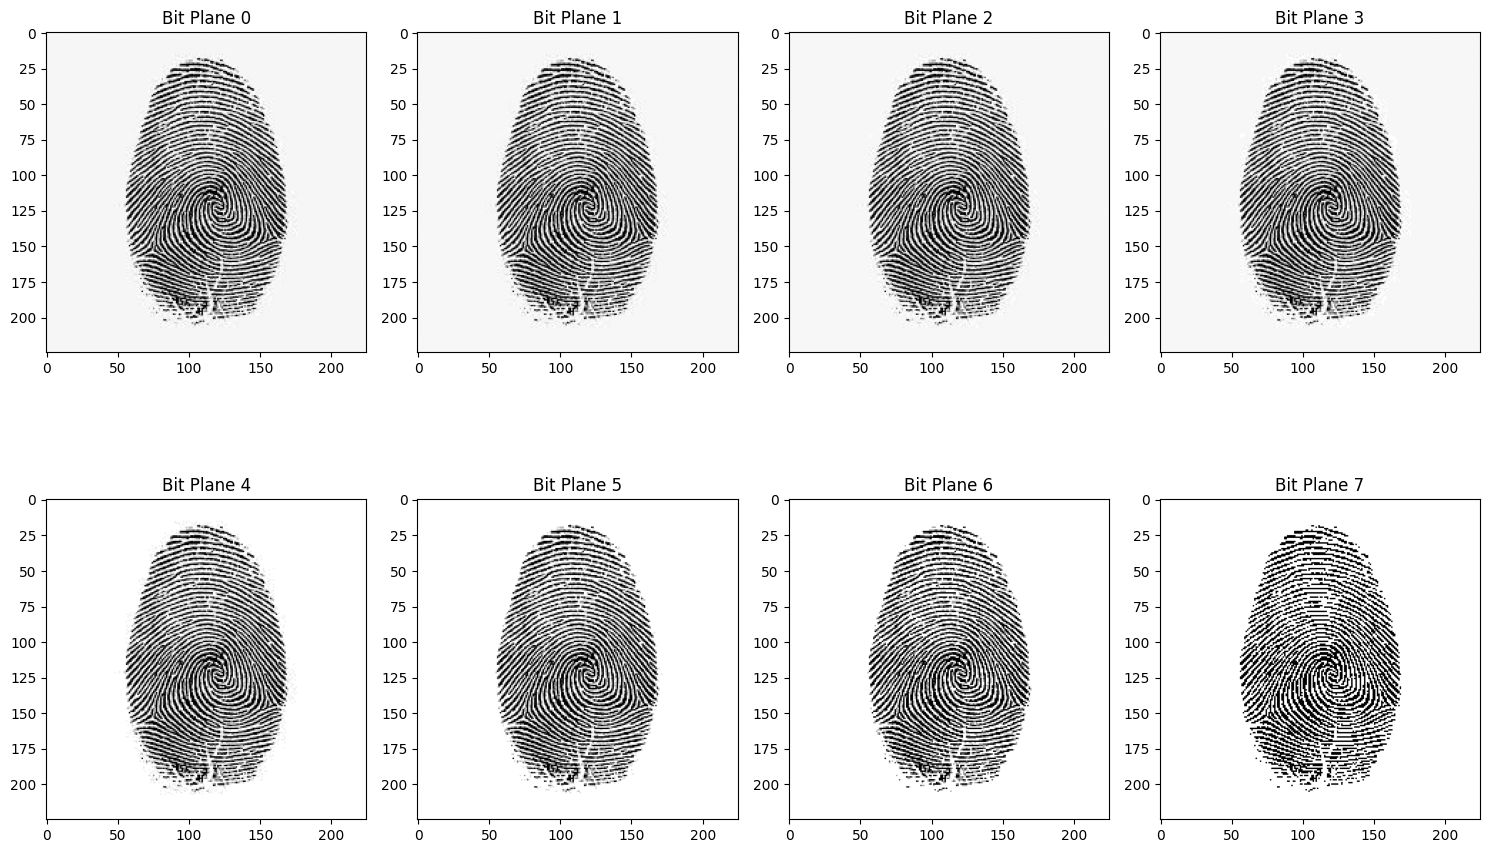

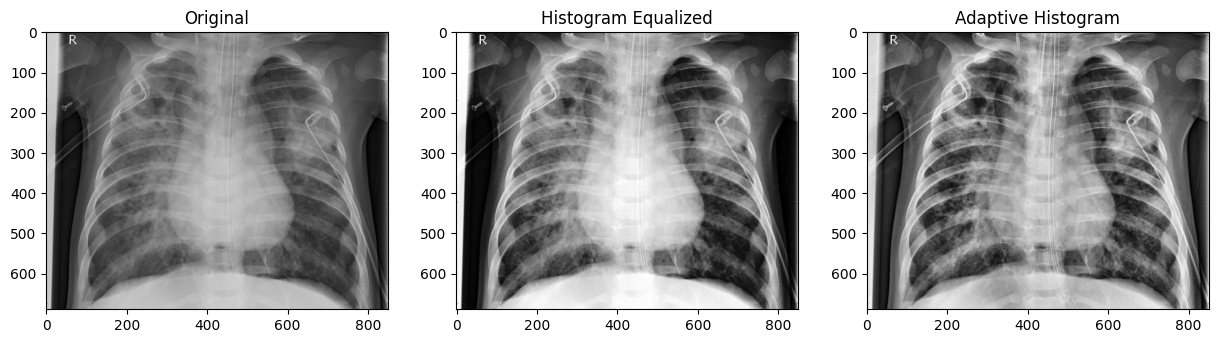

Histogram Equalization improves global contrast, while CLAHE preserves local details
by limiting contrast amplification in homogeneous regions.


In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Utility function to display images
def display_images(original, processed, title1='Original', title2='Processed'):
    plt.figure(figsize=(10, 5))
    plt.subplot(121), plt.imshow(original, cmap='gray'), plt.title(title1)
    plt.subplot(122), plt.imshow(processed, cmap='gray'), plt.title(title2)
    plt.show()

# 1. Isolated Point Detection using Laplacian
def detect_isolated_points(image_path):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    laplacian = cv2.Laplacian(img, cv2.CV_64F)
    laplacian_abs = cv2.convertScaleAbs(laplacian)
    _, threshold = cv2.threshold(laplacian_abs, 30, 255, cv2.THRESH_BINARY)
    display_images(img, threshold, 'Original', 'Isolated Points Detected')
    return threshold

# 2. Image Negative
def apply_negative(image_path, image_type='gray'):
    if image_type == 'color':
        img = cv2.imread(image_path, cv2.IMREAD_COLOR)
        negative = 255 - img
        plt.imshow(cv2.cvtColor(negative, cv2.COLOR_BGR2RGB))
        plt.title('Color Negative')
        plt.show()
    else:
        img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
        if image_type == 'binary':
            _, img = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)
        negative = 255 - img
        display_images(img, negative, f'{image_type.capitalize()} Original', f'{image_type.capitalize()} Negative')
    return negative

# 3. Contrast Stretching
def contrast_stretching(image_path):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    min_val = np.min(img)
    max_val = np.max(img)
    stretched = ((img - min_val) / (max_val - min_val) * 255).astype(np.uint8)
    equalized = cv2.equalizeHist(img)
    plt.figure(figsize=(15, 5))
    plt.subplot(131), plt.imshow(img, cmap='gray'), plt.title('Original')
    plt.subplot(132), plt.imshow(stretched, cmap='gray'), plt.title('Contrast Stretched')
    plt.subplot(133), plt.imshow(equalized, cmap='gray'), plt.title('Histogram Equalized')
    plt.show()
    print("Contrast Stretching: Linear scaling of intensity values\nHistogram Equalization: Non-linear redistribution of intensities")
    return stretched

# 4. Gray Level Slicing
def gray_level_slicing(image_path, lower=100, upper=200):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    sliced = np.where((img >= lower) & (img <= upper), 255, img)
    display_images(img, sliced, 'Original', 'Gray Level Sliced')
    return sliced

# 5. Bit Plane Slicing
def bit_plane_slicing(image_path):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    planes = []
    plt.figure(figsize=(15, 10))
    for i in range(8):
        plane = (img >> i) & 1 * 255
        planes.append(plane)
        plt.subplot(2, 4, i+1)
        plt.imshow(plane, cmap='gray')
        plt.title(f'Bit Plane {i}')
    plt.tight_layout()
    plt.show()
    return planes

# 6. Histogram Equalization
def enhance_contrast(image_path):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    equalized = cv2.equalizeHist(img)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    adaptive = clahe.apply(img)
    plt.figure(figsize=(15, 5))
    plt.subplot(131), plt.imshow(img, cmap='gray'), plt.title('Original')
    plt.subplot(132), plt.imshow(equalized, cmap='gray'), plt.title('Histogram Equalized')
    plt.subplot(133), plt.imshow(adaptive, cmap='gray'), plt.title('Adaptive Histogram')
    plt.show()
    print("Histogram Equalization improves global contrast, while CLAHE preserves local details\nby limiting contrast amplification in homogeneous regions.")

# Example usage
if __name__ == "__main__":
    image_path = 'HappyFish.jpg'
    image_path1 = 'fingerprint.jpg'
    image_path2 = 'xray.jpg'
    
    # Task 1
    detect_isolated_points(image_path)
    
    # Task 2
    apply_negative(image_path, 'gray')
    apply_negative(image_path, 'color')
    apply_negative(image_path, 'binary')
    
    # Task 3
    contrast_stretching(image_path)
    
    # Task 4
    gray_level_slicing(image_path)
    
    # Task 5
    bit_plane_slicing(image_path1)
    
    # Task 6
    enhance_contrast(image_path2)